# Experiment 1 vs Experiment 2 - W-estimate skill comparison

Overlays the summary figures from **experiment_1** and **experiment_2**, which are
identical except that experiment_2 passes `extrapolate_to_surface=True` to
`compute_w_planefit` (so its integrated w reaches the surface; its depth grid runs
0 -> -70 m instead of -8 -> -70 m).

Reproduces Figures **2a-2d** (skill vs array width) and **5a-5d** (skill vs depth)
from `experiment_*/summary.ipynb`, plotting both experiments on the same axes.

Encoding used throughout:

- **colour** = the within-method knob (cell centre latitude / gliders-per-cell for
  2a-c / 5a-c; **cell shape** - diamond / hexagon / square - for 2d / 5d).
- **linestyle + marker fill** = experiment: **exp1 = solid, filled marker**;
  **exp2 = dashed, open marker**.
- **marker shape** (2d / 5d only) = cell height (o = 1deg tall, ^ = 2deg tall).

Everything is read from `experiment_*/data/`; figures are written to this folder.
Run in place after both experiments have populated their `data/`.

In [1]:
import os, sys
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

REPO = "/home/edavenport/analysis/tpose24-osse"
sys.path.insert(0, REPO)
import osse_tools as ot

OUTDIR = os.path.join(REPO, "compare_exp_1_2"); os.makedirs(OUTDIR, exist_ok=True)
plt.rcParams["figure.dpi"] = 120

EXP_ROOT = {1: os.path.join(REPO, "experiment_1"), 2: os.path.join(REPO, "experiment_2")}
M = {e: pd.read_csv(os.path.join(EXP_ROOT[e], "data", "metrics.csv")) for e in (1, 2)}

# experiment_2 == experiment_1 but with extrapolate_to_surface=True in compute_w_planefit
EXP_STYLE = {
    1: dict(ls="-",  fill=True,  lbl="exp1 (no surface extrap)"),
    2: dict(ls="--", fill=False, lbl="exp2 (extrap to surface)"),
}

def load_cell(exp, row):
    """Open the saved w_est/w_model/bias arrays for one metrics row of an experiment."""
    return xr.open_dataset(os.path.join(EXP_ROOT[exp], row.nc_path))

def mfc(exp, color):
    """Marker face colour: filled (exp1) or open/white (exp2)."""
    return color if EXP_STYLE[exp]["fill"] else "white"

def exp_handles():
    """Legend handles distinguishing the two experiments by line style only
    (marker fill is a redundant cue on the data lines; here the solid-vs-dashed
    line is what the reader needs to see)."""
    return [Line2D([0], [0], color="0.3", ls=EXP_STYLE[e]["ls"], lw=1.9,
                   label=EXP_STYLE[e]["lbl"]) for e in (1, 2)]

# longer legend handles so the solid-vs-dashed line style is clearly visible
EXP_LEG = dict(title="experiment", fontsize=8, loc="best", handlelength=3.2)

print({e: len(M[e]) for e in (1, 2)})

{1: 96, 2: 96}


In [2]:
# Style dictionaries and geometry-panel helpers, copied verbatim from
# experiment_1/summary.ipynb so the comparison figures match the originals.
LAT_COLORS = {
    -1.5: "#08306b", -1.0: "#2171b5", -0.5: "#6baed6",
     0.0: "#111111",
     0.5: "#fb6a4a",  1.0: "#cb181d",  1.5: "#67000d",
}
GLIDER_COLORS = {2: "#440154", 4: "#21918c", 6: "#9fda3a"}
# equator single-cell: colour = SHAPE, marker = cell HEIGHT (linestyle is reserved
# for the experiment here: solid = exp1, dashed = exp2).
EQS_SHAPE_COLOR = {"diamond": "#1f77b4", "hexagon": "#2ca02c", "square": "#d62728"}
EQS_HEIGHT_MK   = {1.0: "o", 2.0: "^"}           # cell_height_deg -> marker
EQS_META = {                                     # pattern -> (shape, height_deg)
    "equator_1deg":    ("diamond", 1.0), "equator_2deg":    ("diamond", 2.0),
    "equator_hex1deg": ("hexagon", 1.0), "equator_hex2deg": ("hexagon", 2.0),
    "equator_sq1deg":  ("square",  1.0), "equator_sq2deg":  ("square",  2.0),
}
EQS_STYLE = {pat: dict(color=EQS_SHAPE_COLOR[sh], mk=EQS_HEIGHT_MK[h],
                       lbl=f"{h:g}deg {sh}", shape=sh, height=h)
             for pat, (sh, h) in EQS_META.items()}
EQS_PATS = ["equator_1deg", "equator_2deg", "equator_hex1deg", "equator_hex2deg",
            "equator_sq1deg", "equator_sq2deg"]

def _lat_lbl(v): return f"{v:+.1f}"

def _hull_poly(pts):
    pts = np.array(pts, float)
    c = pts.mean(0)
    order = np.argsort(np.arctan2(pts[:, 1] - c[1], pts[:, 0] - c[0]))
    p = pts[order]
    return np.vstack([p, p[0]])

def _layout_legend(ax, loc="upper right"):
    ax.plot([], [], marker="s", ls="", color="0.55", ms=6, label="mooring")
    ax.plot([], [], marker="o", ls="", color="0.4", mec="k", mew=0.3, ms=6, label="glider")
    ax.legend(fontsize=7, loc=loc)

def _stacked_cells_panel(ax, cells, half, title, off_demo=0.5):
    vlats = sorted({c + s * half for c in cells for s in (-1, 1)} | set(cells))
    moor = [v for v in vlats if abs(v - round(v)) < 1e-9]
    ax.plot([0, 0], [min(vlats), max(vlats)], color="0.8", lw=0.8, zorder=1)
    ax.plot([0] * len(moor), moor, marker="s", ls="", color="0.55", ms=6, zorder=3)
    for c in cells:
        col = LAT_COLORS[c]
        ax.plot([-off_demo, off_demo], [c, c], marker="o", ls="", color=col,
                ms=6, mec="k", mew=0.3, zorder=4)
        poly = _hull_poly([(0, c + half), (off_demo, c), (0, c - half), (-off_demo, c)])
        ax.plot(poly[:, 0], poly[:, 1], "-", color=col, lw=1.8, zorder=2)
        ax.fill(poly[:, 0], poly[:, 1], color=col, alpha=0.07, zorder=0)
        ax.text(off_demo + 0.16, c, f"{c:+.1f}", va="center", ha="left", fontsize=7, color=col)
    _layout_legend(ax, loc="upper right")
    ax.set_aspect("equal"); ax.set_xlim(-1.0, 2.0)
    ax.set_ylim(min(vlats) - 0.4, max(vlats) + 0.4)
    ax.set_xticks([]); ax.set_yticks(moor); ax.set_ylabel("lat (deg)")
    ax.set_title(title); ax.grid(alpha=0.2, axis="y")

def _density_geometry_panel(ax, off_demo=0.5):
    rows_by_ng = {2: [0.5], 4: [0.25, 0.75], 6: [0.25, 0.5, 0.75]}
    for i, ng in enumerate((2, 4, 6)):
        xc, col = i * 2.0, GLIDER_COLORS[ng]
        ax.plot([xc, xc], [0, 1], color="0.8", lw=0.8, zorder=1)
        ax.plot([xc, xc], [0, 1], marker="s", ls="", color="0.55", ms=6, zorder=3)
        gl = [(xc + s * off_demo, r) for r in rows_by_ng[ng] for s in (-1, 1)]
        ax.plot([p[0] for p in gl], [p[1] for p in gl], marker="o", ls="",
                color=col, ms=6, mec="k", mew=0.3, zorder=4)
        poly = _hull_poly([(xc, 0), (xc, 1)] + gl)
        ax.plot(poly[:, 0], poly[:, 1], "-", color=col, lw=1.8, zorder=2)
        ax.fill(poly[:, 0], poly[:, 1], color=col, alpha=0.08, zorder=0)
        ax.text(xc, -0.4, f"{ng} gliders", ha="center", va="top", fontsize=8, color=col)
    _layout_legend(ax)
    ax.set_aspect("equal"); ax.set_xlim(-1.0, 5.1); ax.set_ylim(-0.8, 1.5)
    ax.set_xticks([]); ax.set_yticks([0, 0.5, 1]); ax.set_ylabel("lat (deg)")
    ax.set_title("glider layout (offset = 0.5deg)")
    ax.grid(alpha=0.2, axis="y")

def _draw_equator_cell(ax, xc, shape, half, color, label, off=0.5):
    if shape == "diamond":
        verts = [(0, half), (off, 0), (0, -half), (-off, 0)]
    elif shape == "hexagon":
        mid = half / 2.0
        verts = [(0, half), (off, mid), (off, -mid), (0, -half), (-off, -mid), (-off, mid)]
    else:                                       # square (box): 4 corner gliders
        verts = [(off, half), (off, -half), (-off, -half), (-off, half)]
    # free real moorings on the lon line within the cell's lat span (incl. centre)
    line_moor = [(0.0, ml) for ml in (-2, -1, 0, 1, 2) if -half - 1e-9 <= ml <= half + 1e-9]
    pts = verts + [p for p in line_moor if p not in verts]
    is_moor = lambda x, y: abs(x) < 1e-9 and abs(y - round(y)) < 1e-9
    ax.plot([xc, xc], [-half, half], color="0.8", lw=0.8, zorder=1)
    mo = [(xc + x, y) for x, y in pts if is_moor(x, y)]
    gl = [(xc + x, y) for x, y in pts if not is_moor(x, y)]
    ax.plot([p[0] for p in mo], [p[1] for p in mo], marker="s", ls="",
            color="0.55", ms=6, zorder=3)
    ax.plot([p[0] for p in gl], [p[1] for p in gl], marker="o", ls="",
            color=color, ms=6, mec="k", mew=0.3, zorder=4)
    poly = _hull_poly([(xc + x, y) for x, y in verts])
    ax.plot(poly[:, 0], poly[:, 1], "-", color=color, lw=1.8, zorder=2)
    ax.fill(poly[:, 0], poly[:, 1], color=color, alpha=0.08, zorder=0)
    ax.text(xc, -1.45, label, ha="center", va="top", fontsize=7.5, color=color)

def _equator_single_geometry(ax):
    layout = [("diamond", 0.5), ("diamond", 1.0),
              ("hexagon", 0.5), ("hexagon", 1.0),
              ("square",  0.5), ("square",  1.0)]
    for i, (shape, half) in enumerate(layout):
        _draw_equator_cell(ax, i * 2.0, shape, half, EQS_SHAPE_COLOR[shape],
                           f"{2 * half:g}deg {shape}")
    _layout_legend(ax, loc="upper right")
    ax.set_aspect("equal"); ax.set_xlim(-1.0, 11.0); ax.set_ylim(-1.9, 1.5)
    ax.set_xticks([]); ax.set_yticks([-1, 0, 1]); ax.set_ylabel("lat (deg)")
    ax.set_title("cell geometry (offset = 0.5deg)")
    ax.grid(alpha=0.2, axis="y")

## Figures 2a-2d - skill vs array width, exp1 vs exp2

One figure per method. Panels 1-2: normalized error and correlation vs glider
offset, with exp1 (solid, filled) and exp2 (dashed, open) overlaid; colour is the
within-method knob. Panel 4: the fixed platform layout (identical for both
experiments).

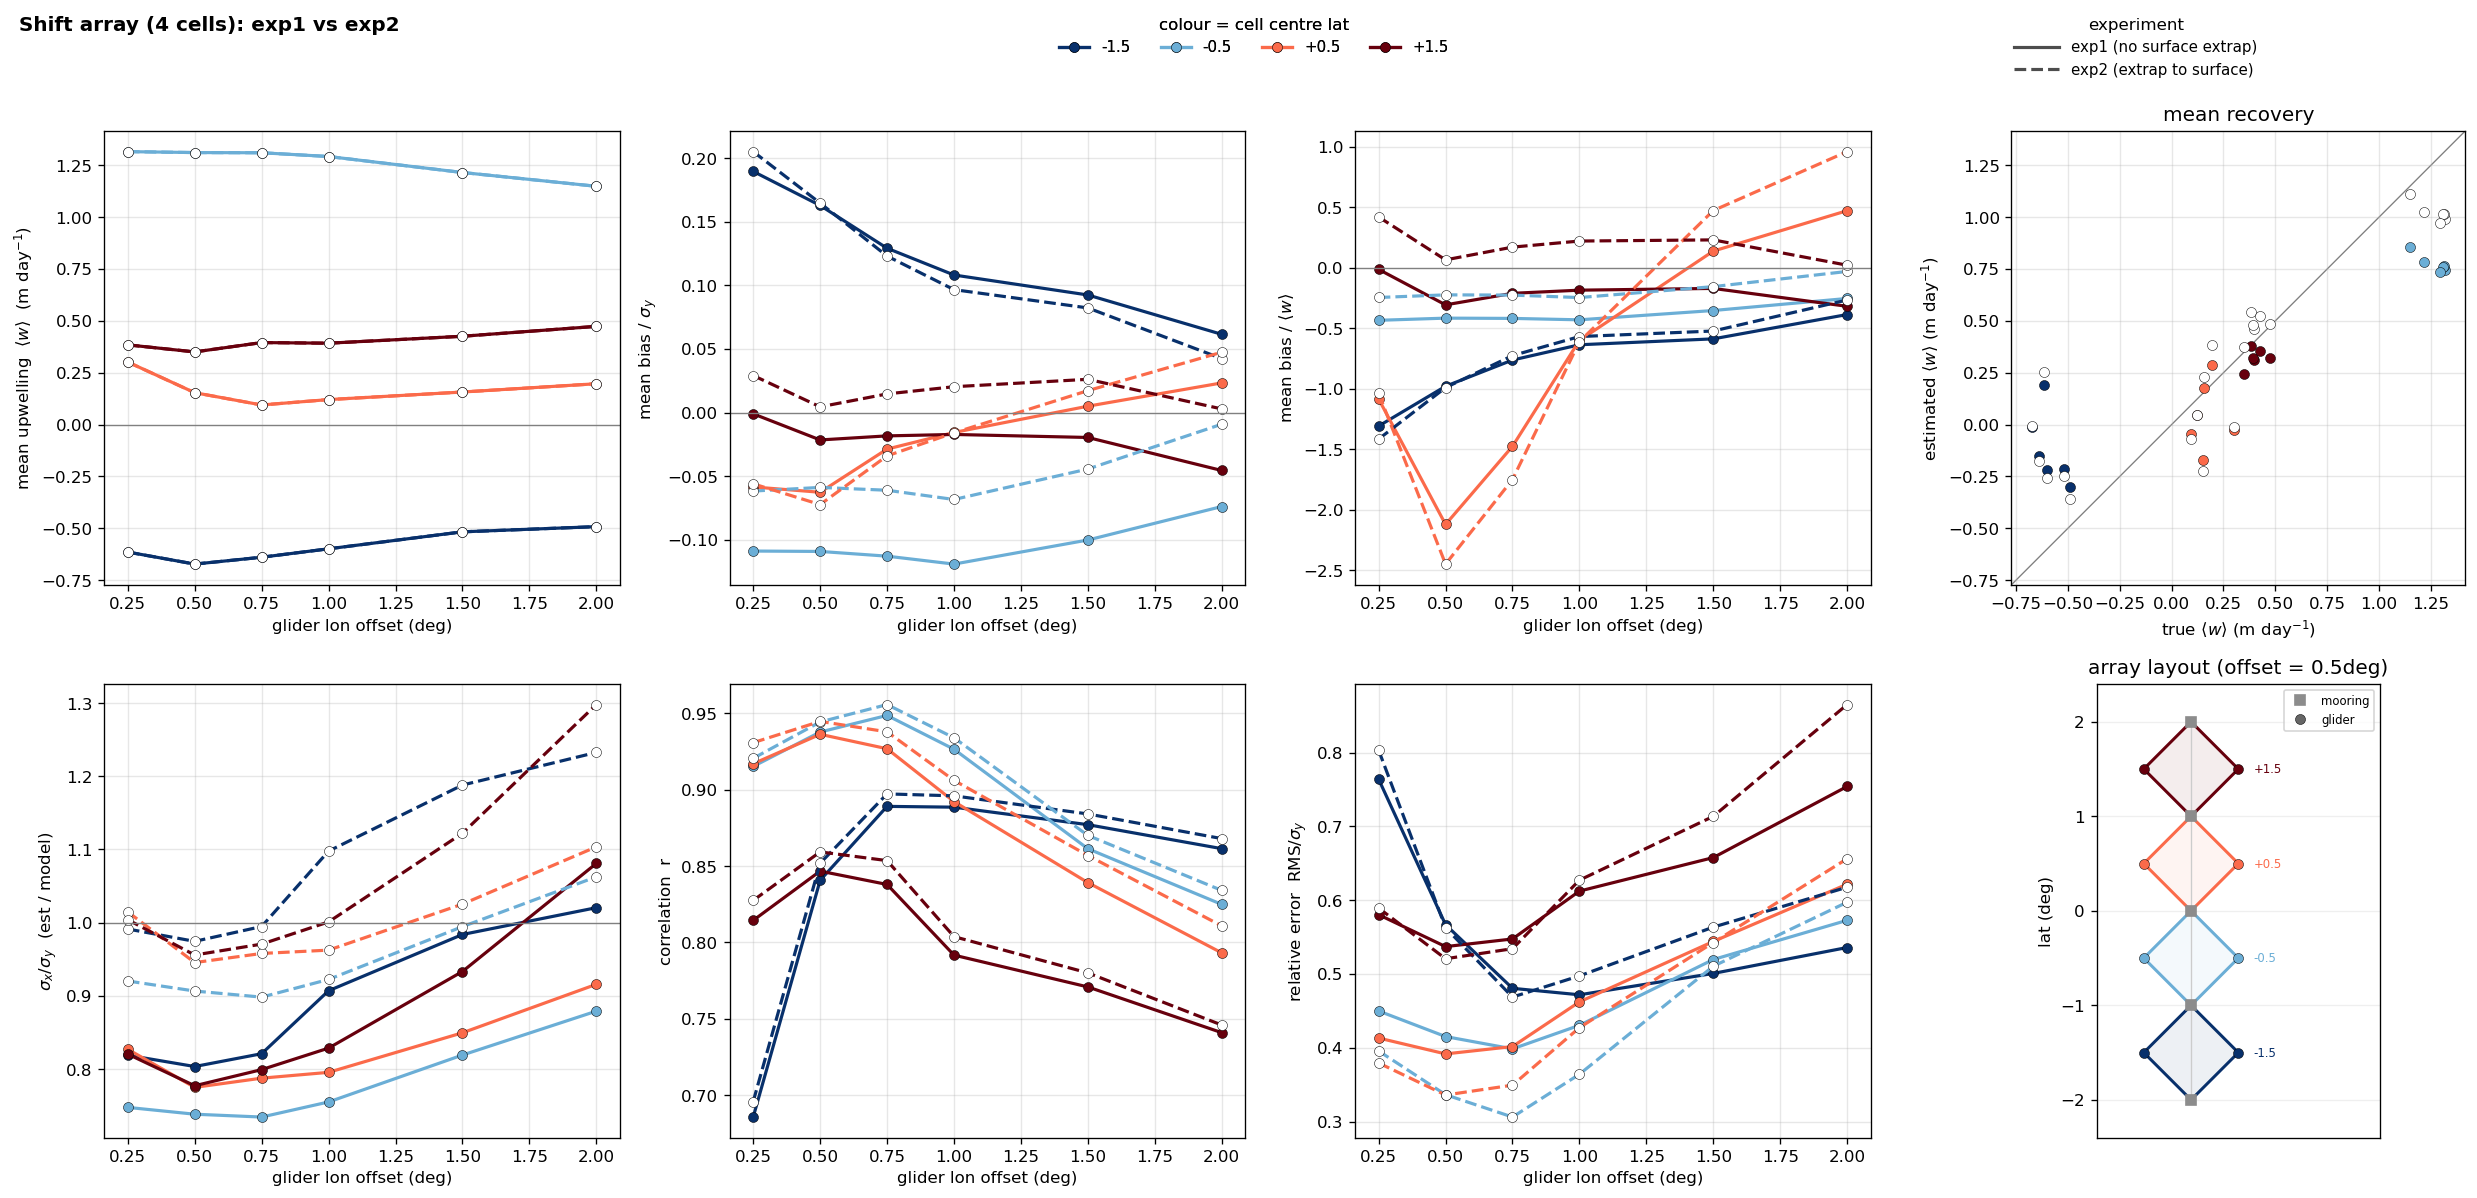

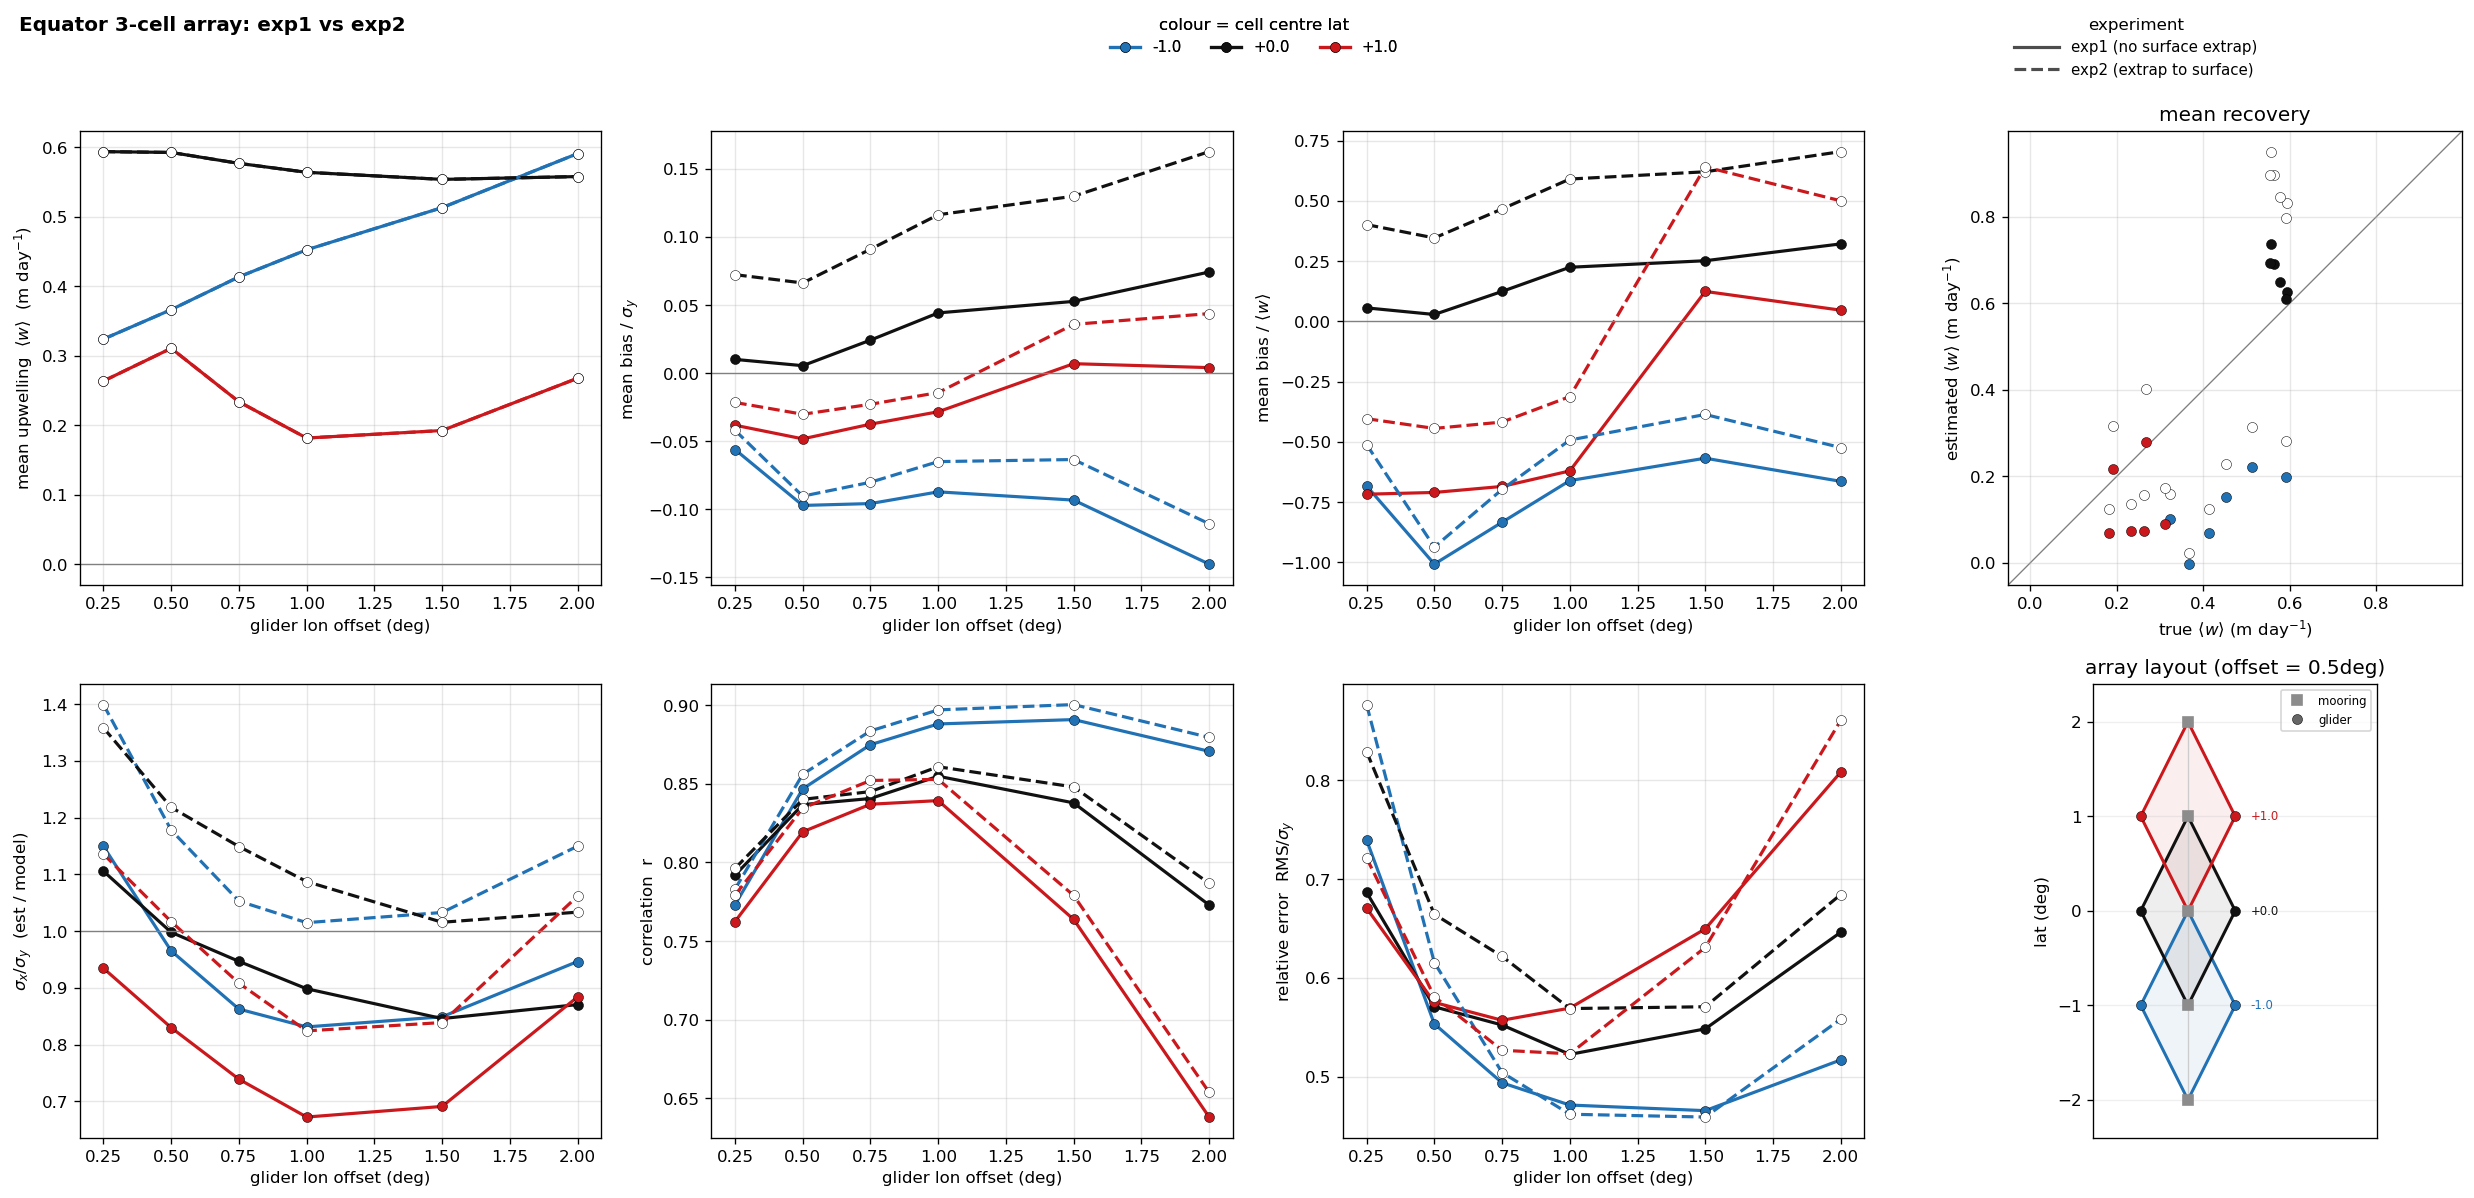

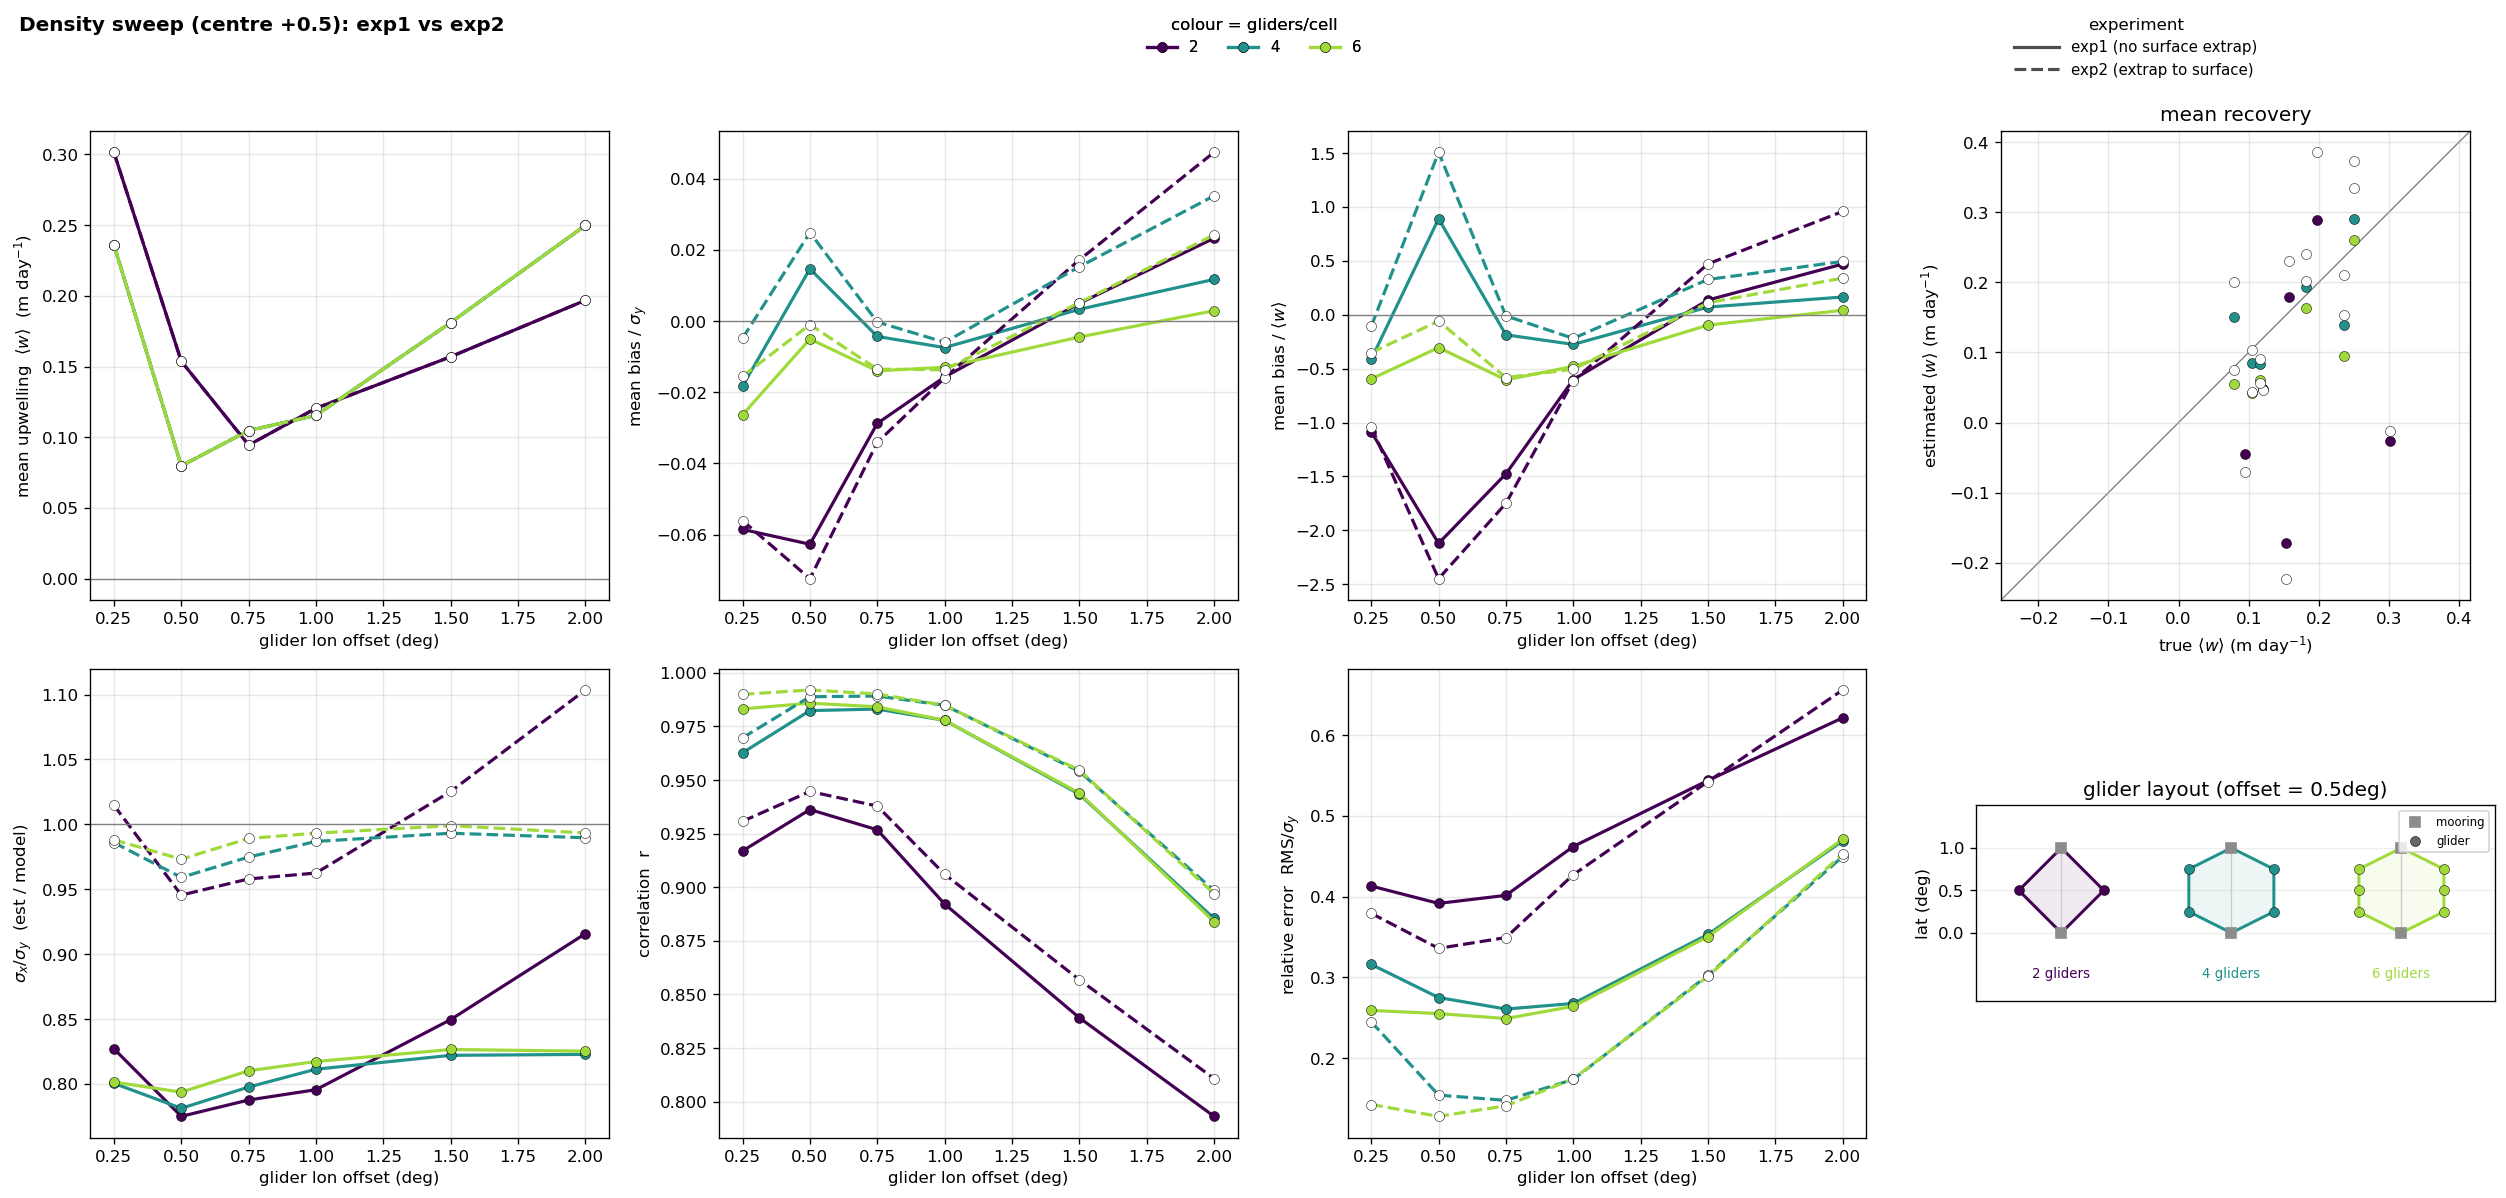

In [3]:
# Figures 2a/2b/2c - single-key methods via a generic loop; both experiments
# overlaid on a 2x4 grid that separates the MEAN from the FLUCTUATIONS:
#   row 1  <w>_model (mean upwelling) | mean bias / sigma_y | mean bias / <w> | est-vs-true mean scatter
#   row 2  sigma_x / sigma_y          | correlation         | relative error RMS/sigma_y | geometry
# exp1 = solid / filled markers, exp2 = dashed / open markers (EXP_STYLE + mfc()).
# w-dimensioned panels are drawn in m/day (raw values are ~1e-5 m/s).
W2DAY = 86400.0                                  # m/s -> m/day

def _scatter_kw(kw):
    """Marker-only style for the mean-recovery scatter, derived from a line's kwargs."""
    sk = {k: v for k, v in kw.items()
          if k in ("color", "ms", "mec", "mew", "mfc", "alpha")}
    sk.update(ls="", marker=kw.get("marker", "o"))
    return sk

def _fill_skill_panels(ax, series):
    """Fill the 7 metric panels of a 2x4 grid; geometry (ax[1,3]) is left to the
    caller. series: iterable of (dd, line_kw[, scatter_kw]); dd is one line's rows
    sorted by width. ax[0,3] is the estimated-vs-true mean scatter."""
    for item in series:
        dd, kw = item[0], item[1]
        skw = item[2] if len(item) > 2 and item[2] else _scatter_kw(kw)
        w = dd.width
        ax[0, 0].plot(w, dd.w_model_mean * W2DAY, **kw)
        ax[0, 1].plot(w, dd.mean_bias / dd.w_model_std, **kw)
        ax[0, 2].plot(w, ot.frac_mean_bias(dd.mean_bias, dd.w_model_mean), **kw)
        ax[0, 3].plot(dd.w_model_mean * W2DAY, dd.w_est_mean * W2DAY, **skw)
        ax[1, 0].plot(w, dd.w_est_std / dd.w_model_std, **kw)
        ax[1, 1].plot(w, dd["corr"], **kw)
        ax[1, 2].plot(w, dd.norm_rms, **kw)

def _label_skill_panels(ax):
    """Axis labels, reference lines, and the scatter 1:1 line for a filled grid."""
    ax[0, 0].set_ylabel(r"mean upwelling  $\langle w\rangle$  (m day$^{-1}$)")
    ax[0, 0].axhline(0, color="0.5", lw=0.8)
    ax[0, 1].set_ylabel(r"mean bias / $\sigma_y$")
    ax[0, 1].axhline(0, color="0.5", lw=0.8)
    ax[0, 2].set_ylabel(r"mean bias / $\langle w\rangle$")
    ax[0, 2].axhline(0, color="0.5", lw=0.8)
    ax[1, 0].set_ylabel(r"$\sigma_x/\sigma_y$  (est / model)")
    ax[1, 0].axhline(1, color="0.5", lw=0.8)
    ax[1, 1].set_ylabel("correlation  r")
    ax[1, 2].set_ylabel(r"relative error  RMS/$\sigma_y$")
    for a in (ax[0, 0], ax[0, 1], ax[0, 2], ax[1, 0], ax[1, 1], ax[1, 2]):
        a.set_xlabel("glider lon offset (deg)"); a.grid(alpha=0.3)
    sc = ax[0, 3]
    lims = [*sc.get_xlim(), *sc.get_ylim()]
    lo, hi = min(lims), max(lims)
    sc.plot([lo, hi], [lo, hi], color="0.5", lw=0.8, zorder=0)
    sc.set_xlim(lo, hi); sc.set_ylim(lo, hi); sc.set_aspect("equal", "box")
    sc.set_xlabel(r"true $\langle w\rangle$ (m day$^{-1}$)")
    sc.set_ylabel(r"estimated $\langle w\rangle$ (m day$^{-1}$)")
    sc.set_title("mean recovery"); sc.grid(alpha=0.3)

PANELS = [
    ("2a_shift", "Shift array (4 cells)", lambda mm: mm.family == "shift",
     "center_lat", LAT_COLORS, "cell centre lat", _lat_lbl,
     lambda ax: _stacked_cells_panel(ax, [-1.5, -0.5, 0.5, 1.5], 0.5,
                                     "array layout (offset = 0.5deg)")),
    ("2b_equator3cell", "Equator 3-cell array", lambda mm: mm.pattern == "equator_3cell",
     "center_lat", LAT_COLORS, "cell centre lat", _lat_lbl,
     lambda ax: _stacked_cells_panel(ax, [-1.0, 0.0, 1.0], 1.0,
                                     "array layout (offset = 0.5deg)")),
    ("2c_density", "Density sweep (centre +0.5)", lambda mm: mm.family == "density",
     "n_gliders_cell", GLIDER_COLORS, "gliders/cell", lambda v: f"{int(v)}",
     _density_geometry_panel),
]
for tag, title, maskfn, key, cmap, leg_title, lbl, geom in PANELS:
    keys = sorted(M[1][maskfn(M[1])][key].unique())
    fig, axes = plt.subplots(2, 4, figsize=(21, 10))
    series = []
    for exp in (1, 2):
        st = EXP_STYLE[exp]; d = M[exp][maskfn(M[exp])]
        for kv in keys:
            dd = d[d[key] == kv].drop_duplicates("width").sort_values("width")
            series.append((dd, dict(color=cmap[kv], ls=st["ls"], marker="o",
                                    lw=1.9, ms=6, mec="k", mew=0.3,
                                    mfc=mfc(exp, cmap[kv]))))
    _fill_skill_panels(axes, series)
    _label_skill_panels(axes)
    col_handles = [Line2D([0], [0], color=cmap[kv], marker="o", mec="k", mew=0.3,
                          lw=1.9, label=lbl(kv)) for kv in keys]
    geom(axes[1, 3])
    fig.tight_layout(rect=[0, 0, 1, 0.93])
    # method label (top-left) + colour & experiment legends across the top
    fig.text(0.01, 0.99, f"{title}: exp1 vs exp2", ha="left", va="top",
             fontsize=12, fontweight="bold")
    lg1 = fig.legend(handles=col_handles, title=f"colour = {leg_title}",
                     loc="upper center", bbox_to_anchor=(0.5, 1.0),
                     ncol=len(col_handles), fontsize=9, title_fontsize=10, frameon=False)
    fig.add_artist(lg1)
    fig.legend(handles=exp_handles(), title="experiment", loc="upper center",
               bbox_to_anchor=(0.85, 1.0), ncol=1, fontsize=9, title_fontsize=10,
               frameon=False, handlelength=3.0)
    fig.savefig(os.path.join(OUTDIR, f"fig{tag}_compare.png"), dpi=150, bbox_inches="tight")
    plt.show()


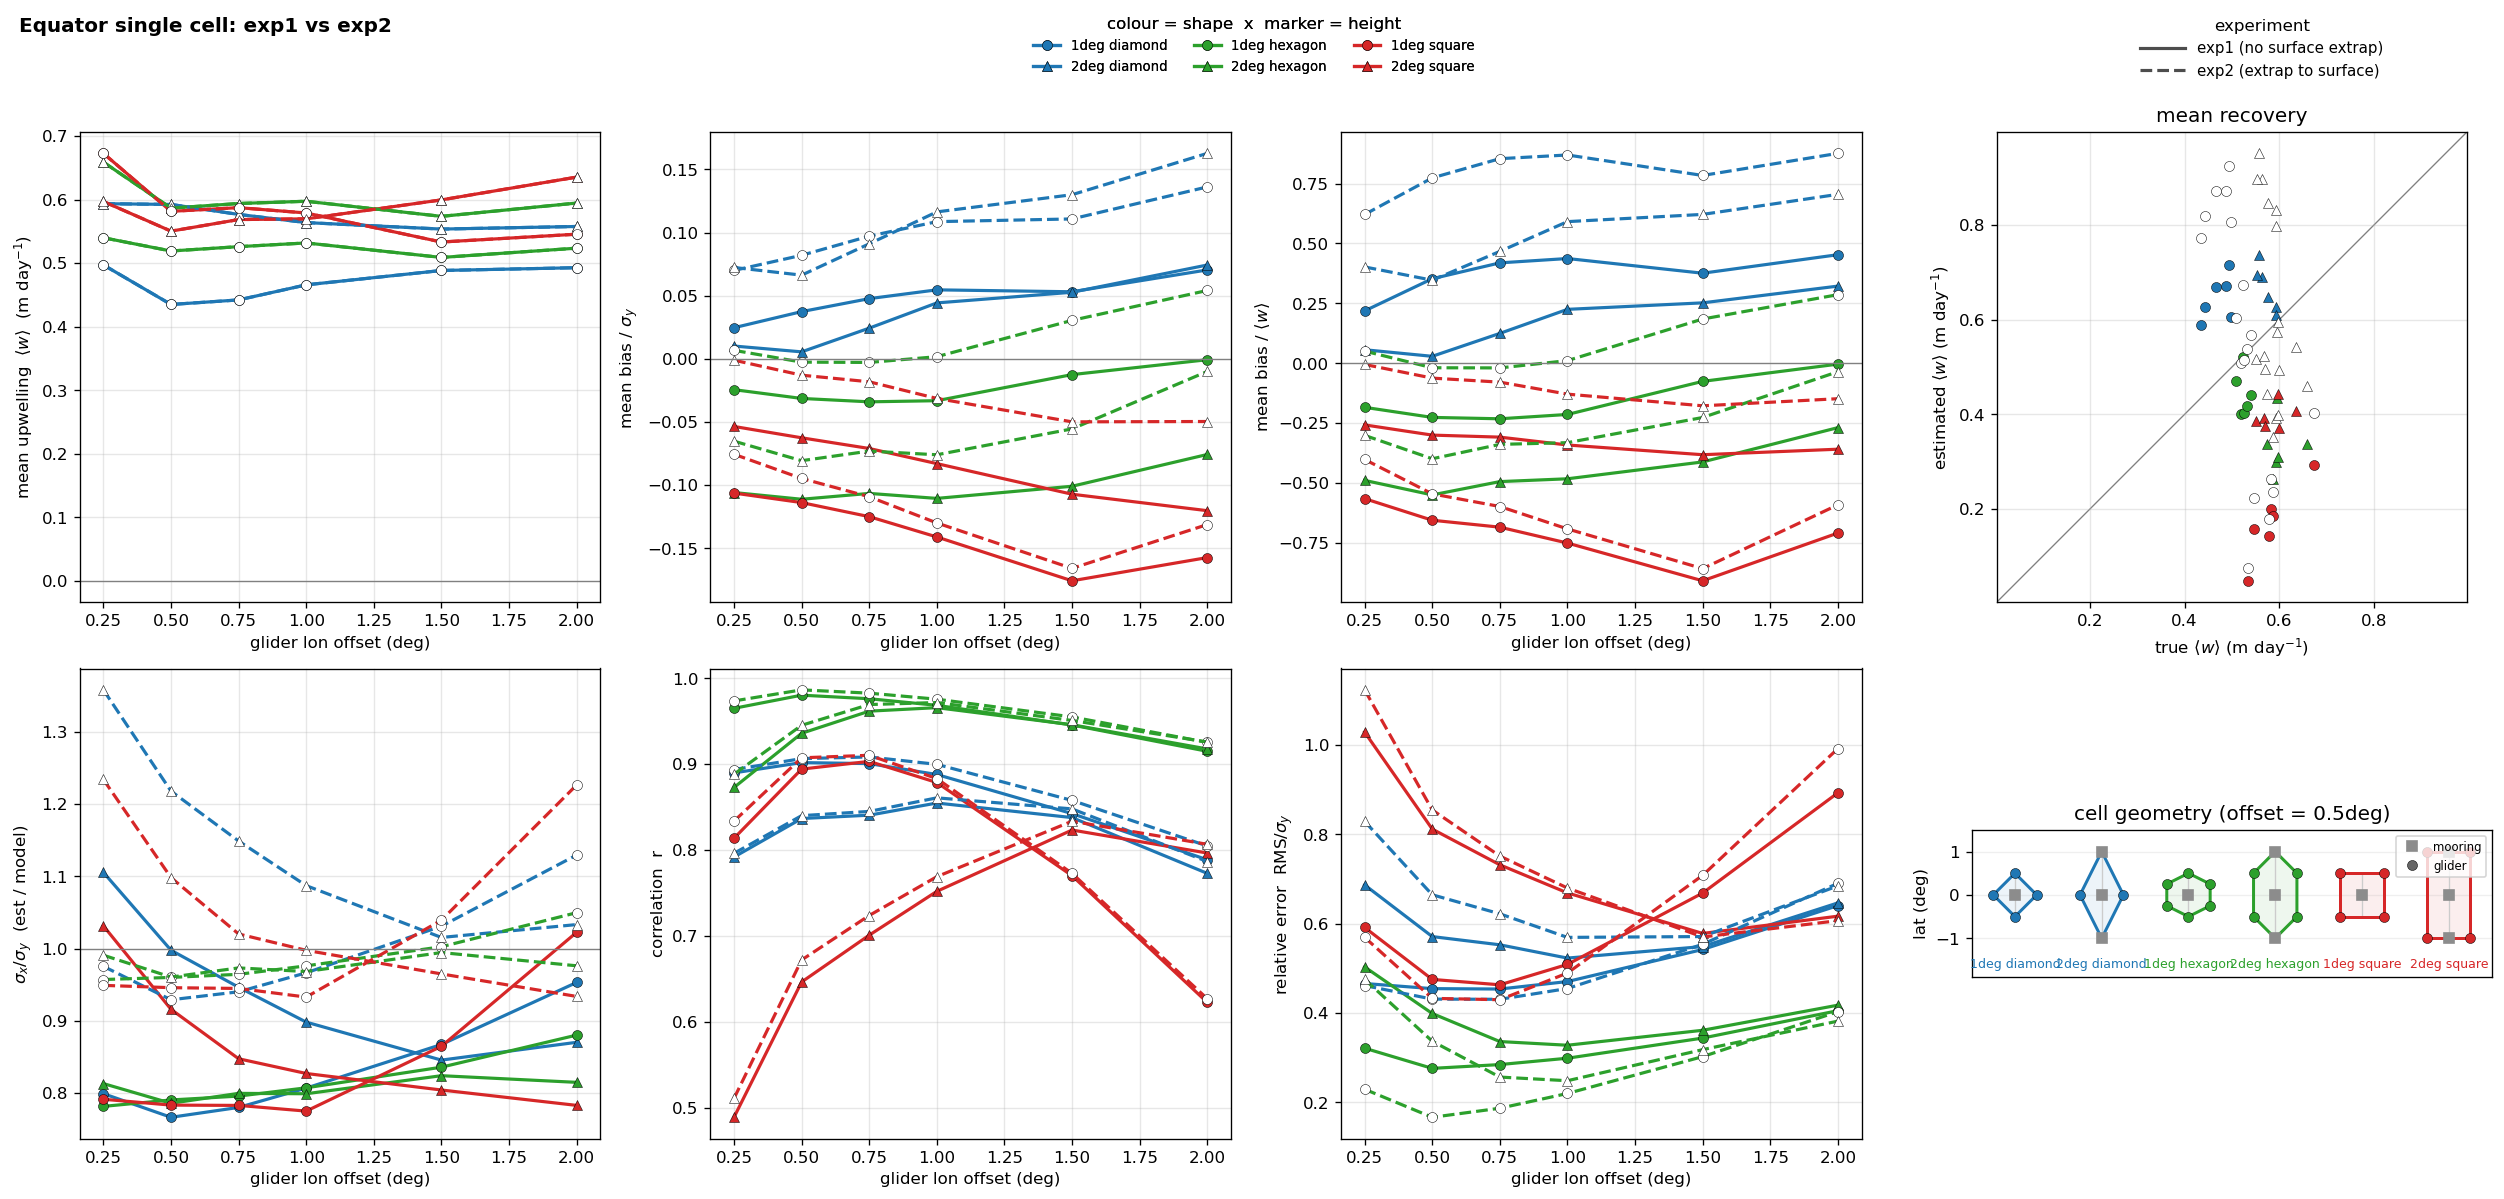

In [4]:
# Figure 2d - equator single cell, diamond/hexagon/square x 1deg/2deg; both
# experiments on the same 2x4 grid. colour = shape, marker = cell height,
# linestyle/fill = experiment (solid+filled exp1, dashed+open exp2). The scatter
# reuses the same per-series marker (height), so it distinguishes both cues.
fig, axes = plt.subplots(2, 4, figsize=(21, 10))
series = []
for exp in (1, 2):
    st = EXP_STYLE[exp]
    for pat in EQS_PATS:
        s = EQS_STYLE[pat]
        dd = M[exp][M[exp].pattern == pat].sort_values("width")
        if dd.empty:
            continue
        series.append((dd, dict(ls=st["ls"], marker=s["mk"], color=s["color"],
                                lw=1.9, ms=6, mec="k", mew=0.3,
                                mfc=mfc(exp, s["color"]))))
_fill_skill_panels(axes, series)
_label_skill_panels(axes)
shape_handles = [Line2D([0], [0], color=EQS_STYLE[p]["color"], marker=EQS_STYLE[p]["mk"],
                        mec="k", mew=0.3, lw=1.9, label=EQS_STYLE[p]["lbl"]) for p in EQS_PATS]
_equator_single_geometry(axes[1, 3])
fig.tight_layout(rect=[0, 0, 1, 0.93])
# method label (top-left) + shape/height & experiment legends across the top
fig.text(0.01, 0.99, "Equator single cell: exp1 vs exp2", ha="left", va="top",
         fontsize=12, fontweight="bold")
lg1 = fig.legend(handles=shape_handles, title="colour = shape  x  marker = height",
                 loc="upper center", bbox_to_anchor=(0.5, 1.0), ncol=3, fontsize=8,
                 title_fontsize=10, frameon=False)
fig.add_artist(lg1)
fig.legend(handles=exp_handles(), title="experiment", loc="upper center",
           bbox_to_anchor=(0.9, 1.0), ncol=1, fontsize=9, title_fontsize=10,
           frameon=False, handlelength=3.0)
fig.savefig(os.path.join(OUTDIR, "fig2d_equator_single_compare.png"), dpi=150, bbox_inches="tight")
plt.show()


## Figures 5a-5d - skill vs depth, exp1 vs exp2

Depth-resolved skill at a fixed glider offset (`DEPTH_WIDTH = 1.0deg` for 5a-5c,
`0.5deg` for 5d), one figure per method. Panels: normalized error, correlation,
fractional mean bias (⟨w_est⟩−⟨w_model⟩)/⟨w_model⟩ (masked at the mean's
zero-crossings), absolute RMS (coloured) vs signal std (grey), and the mean w
profile itself — estimate (coloured) vs model truth (grey). exp1 = solid/filled,
exp2 = dashed/open. Because exp2 extrapolates to the surface, its profiles extend
above -8 m up to 0 m.

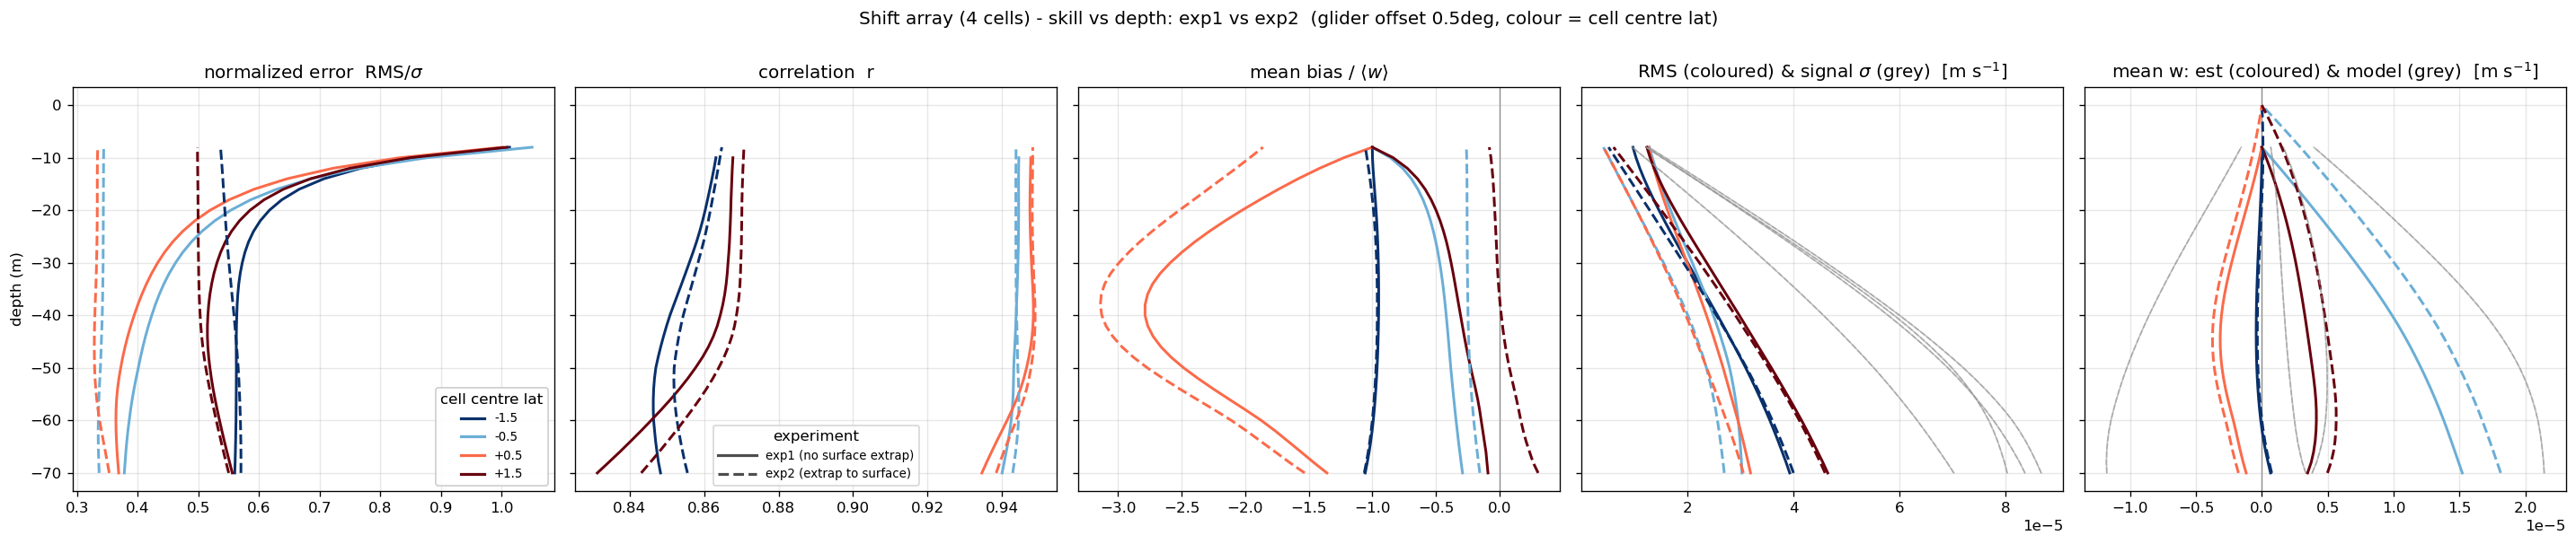

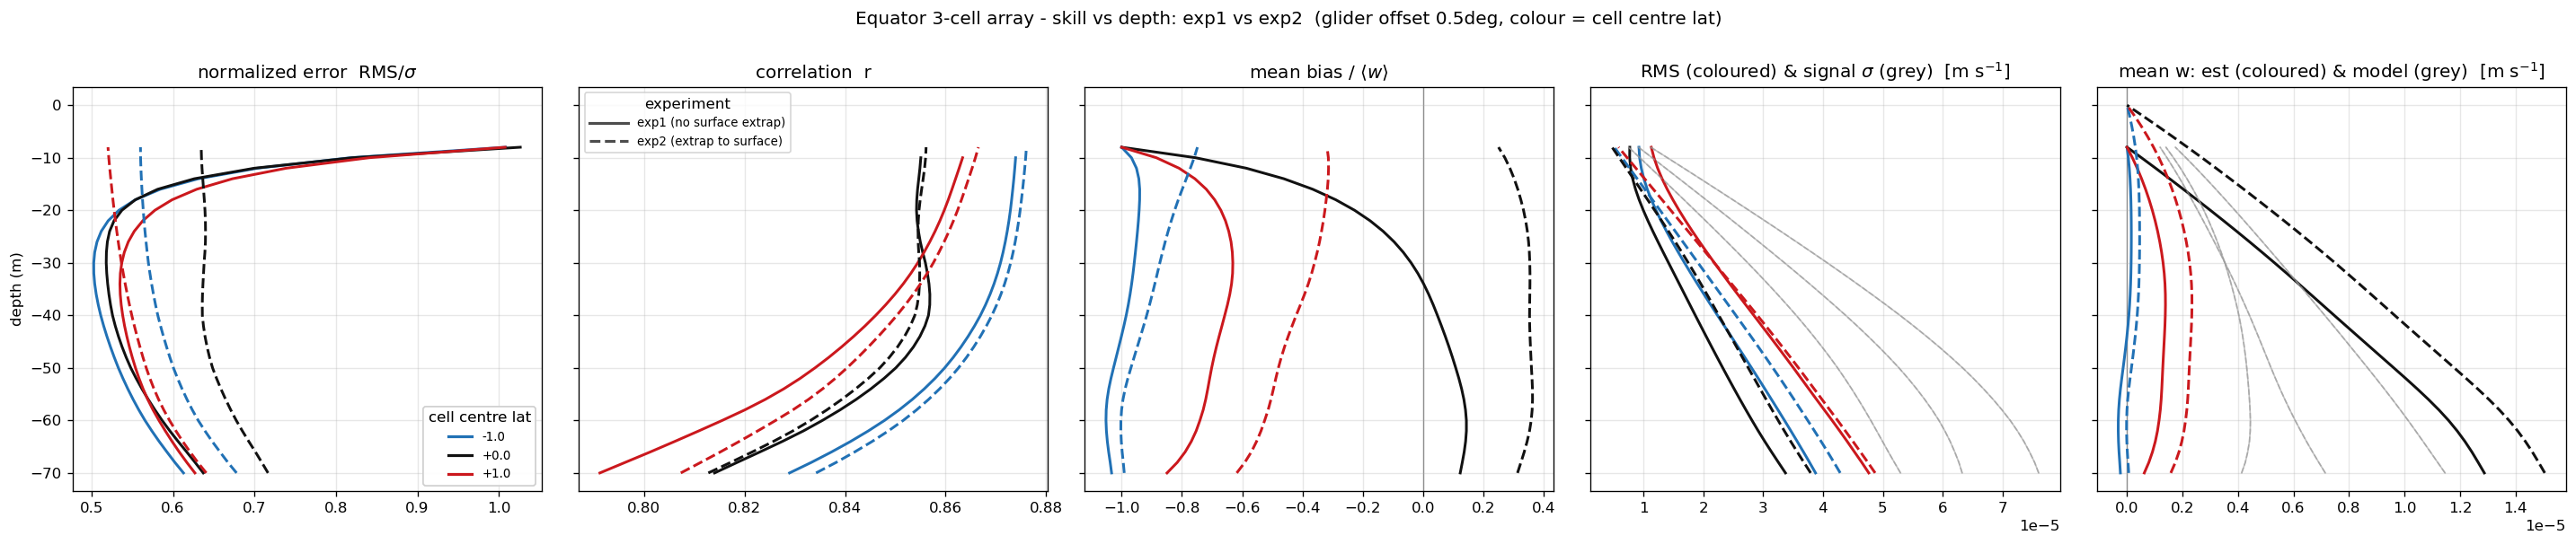

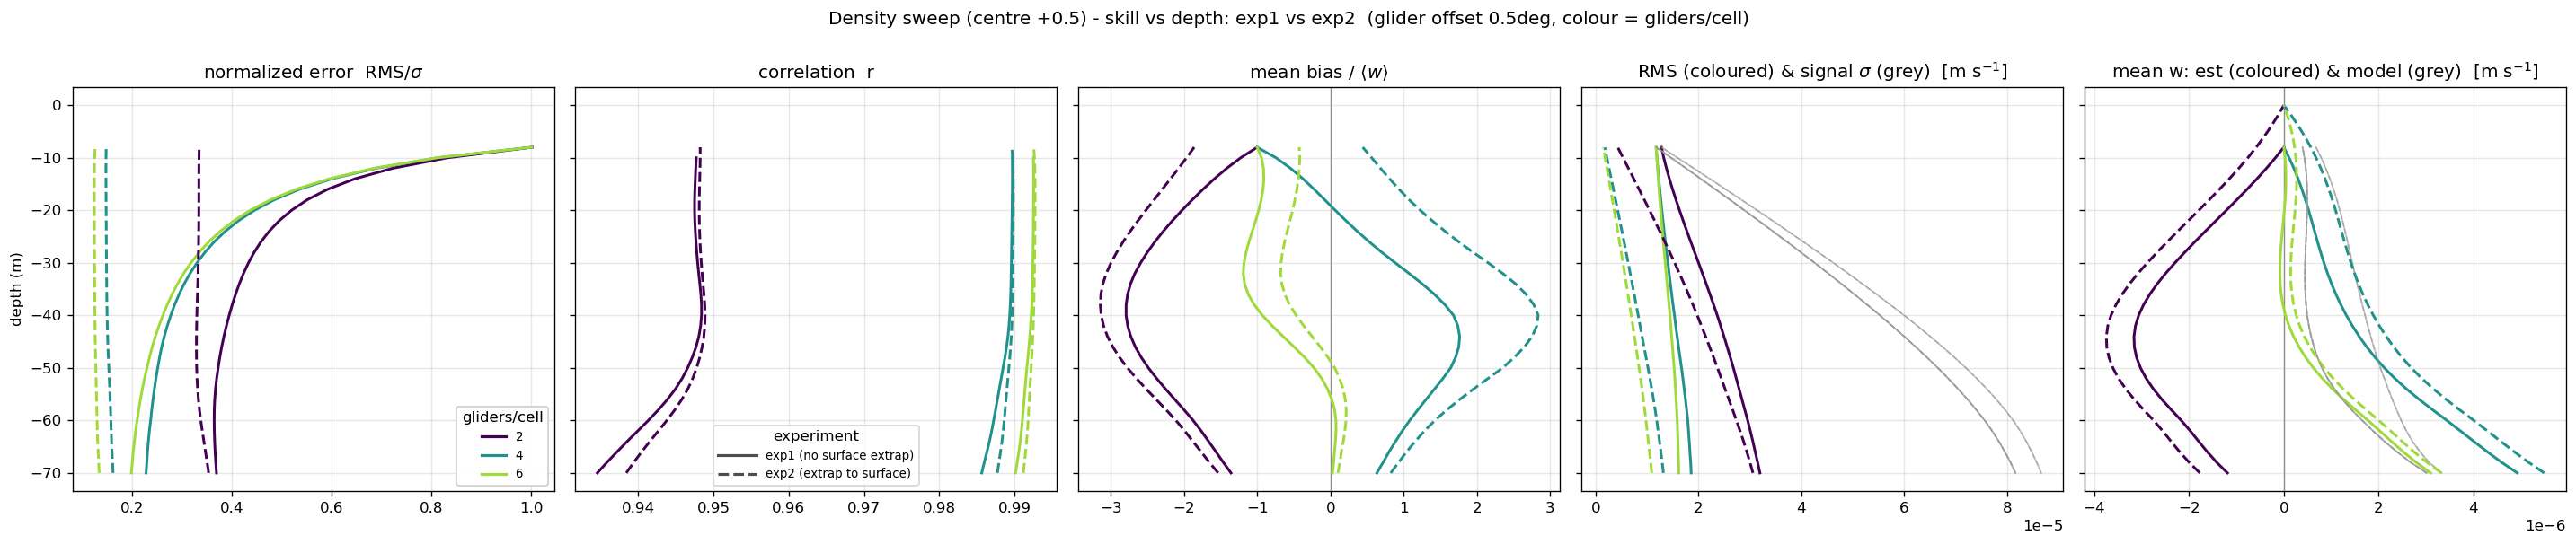

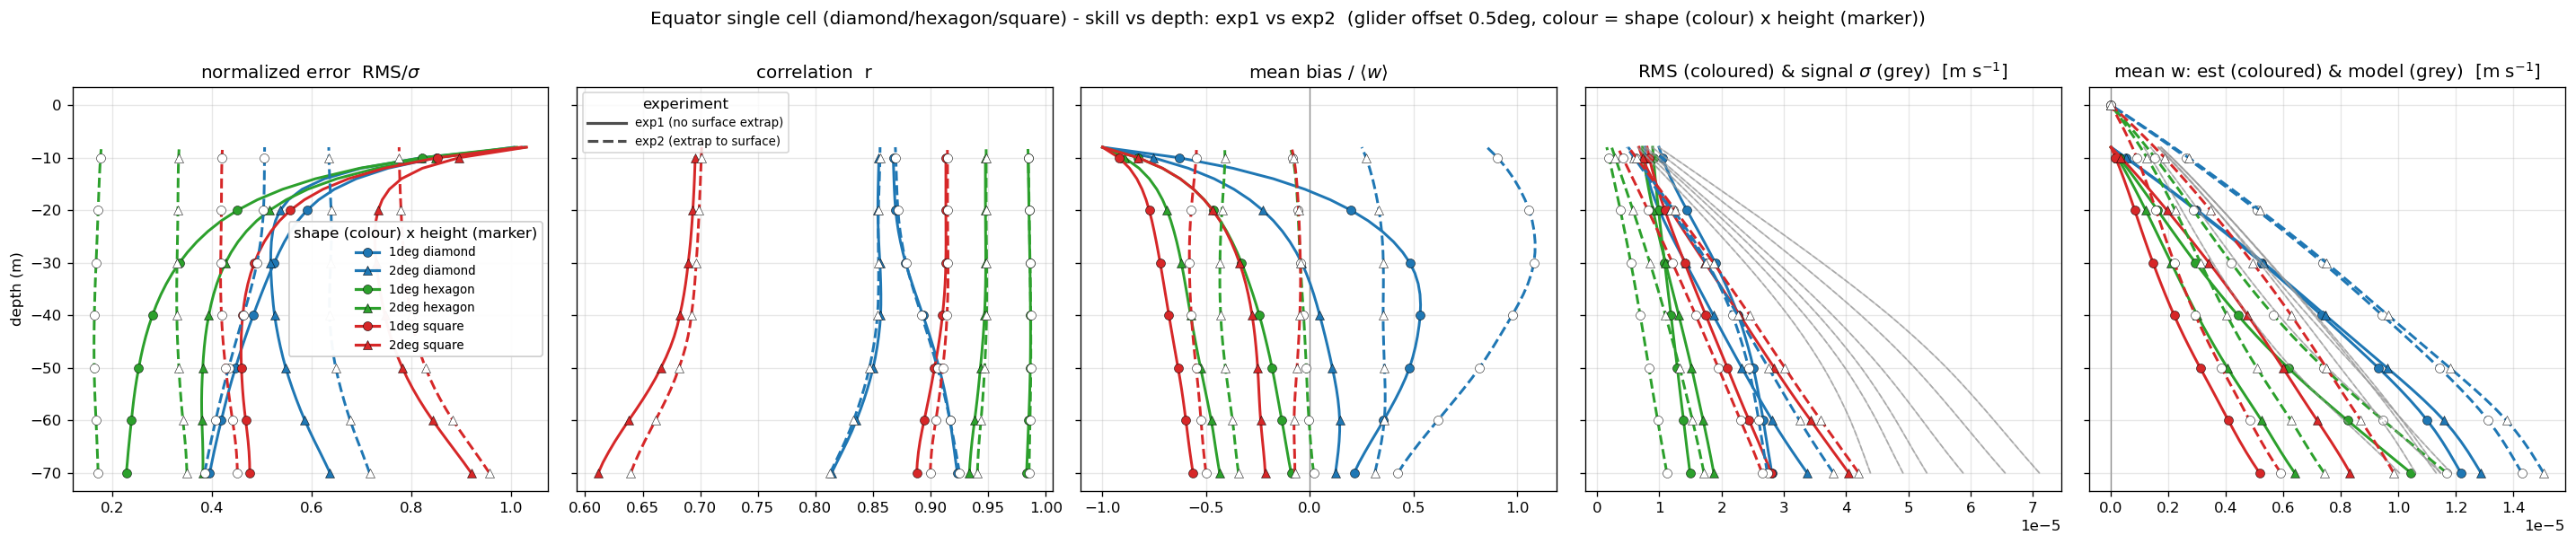

In [5]:
DEPTH_WIDTH = 0.5

def _depth_compare(rows_by_exp, tag, title, leg_title, line_handles, dw=DEPTH_WIDTH):
    """Overlay depth profiles for both experiments. rows_by_exp maps exp -> list of
    (metrics_row, style) with style keys color, lbl and optional mk (marker shape)."""
    fig, axes = plt.subplots(1, 5, figsize=(24, 5), sharey=True)
    for exp in (1, 2):
        est = EXP_STYLE[exp]
        for r, s in rows_by_exp[exp]:
            ds = load_cell(exp, r)
            B = ot.w_skill_by_depth(ds.w_est, ds.w_model).sortby("depth")
            z = B.depth
            common = dict(color=s["color"], ls=est["ls"], lw=1.8,
                          marker=s.get("mk"), markevery=5, ms=6, mec="k", mew=0.3,
                          mfc=mfc(exp, s["color"]))
            axes[0].plot(B.norm_rms, z, **common)
            axes[1].plot(B["corr"], z, **common)
            axes[2].plot(ot.frac_mean_bias(B.mean_bias, B.w_model_mean), z, **common)
            axes[3].plot(B.rms, z, **common)
            axes[3].plot(B.w_model_std, z, color="0.6", ls=est["ls"], lw=1.0, alpha=0.6)
            axes[4].plot(B.w_est_mean, z, **common)
            axes[4].plot(B.w_model_mean, z, color="0.6", ls=est["ls"], lw=1.0, alpha=0.6)
    axes[0].set_title(r"normalized error  RMS/$\sigma$")
    axes[1].set_title("correlation  r")
    axes[2].set_title(r"mean bias / $\langle w \rangle$")
    axes[2].axvline(0, color="0.5", lw=0.8, zorder=0)
    axes[3].set_title(r"RMS (coloured) & signal $\sigma$ (grey)  [m s$^{-1}$]")
    axes[4].set_title(r"mean w: est (coloured) & model (grey)  [m s$^{-1}$]")
    axes[4].axvline(0, color="0.5", lw=0.8, zorder=0)
    axes[0].set_ylabel("depth (m)")
    for ax in axes:
        ax.grid(alpha=0.3)
    leg1 = axes[0].legend(handles=line_handles, title=leg_title, fontsize=8, loc="best")
    axes[0].add_artist(leg1)
    axes[1].legend(handles=exp_handles(), **EXP_LEG)
    fig.suptitle(f"{title} - skill vs depth: exp1 vs exp2  (glider offset {dw:g}deg, "
                 f"colour = {leg_title})", y=1.0)
    fig.tight_layout()
    fig.savefig(os.path.join(OUTDIR, f"fig{tag}_compare.png"), dpi=150, bbox_inches="tight")
    plt.show()

# 5a shift + 5b equator 3-cell: colour = cell centre latitude
for tag, pat, title in (("5a_shift", "shift", "Shift array (4 cells)"),
                        ("5b_equator3cell", "equator_3cell", "Equator 3-cell array")):
    rows_by_exp = {}
    for exp in (1, 2):
        d = M[exp][(M[exp].pattern == pat) & np.isclose(M[exp].width, DEPTH_WIDTH)]
        rows_by_exp[exp] = [(d[np.isclose(d.center_lat, lat)].iloc[0],
                             dict(color=LAT_COLORS[lat], lbl=f"{lat:+.1f}"))
                            for lat in sorted(d.center_lat.unique())]
    lats = sorted(M[1][M[1].pattern == pat].center_lat.unique())
    line_handles = [Line2D([0], [0], color=LAT_COLORS[l], lw=1.9, label=f"{l:+.1f}") for l in lats]
    _depth_compare(rows_by_exp, tag, title, "cell centre lat", line_handles)

# 5c density: colour = gliders-per-cell
rows_by_exp = {}
for exp in (1, 2):
    d = M[exp][(M[exp].family == "density") & np.isclose(M[exp].width, DEPTH_WIDTH)]
    rows_by_exp[exp] = [(d[d.n_gliders_cell == ng].iloc[0],
                         dict(color=GLIDER_COLORS[ng], lbl=f"{int(ng)}"))
                        for ng in sorted(d.n_gliders_cell.unique())]
ngs = sorted(M[1][M[1].family == "density"].n_gliders_cell.unique())
line_handles = [Line2D([0], [0], color=GLIDER_COLORS[ng], lw=1.9, label=f"{int(ng)}") for ng in ngs]
_depth_compare(rows_by_exp, "5c_density", "Density sweep (centre +0.5)", "gliders/cell", line_handles)

# 5d equator single: colour = height, marker = shape; uses the narrower
# DEPTH_WIDTH_5D glider offset.
rows_by_exp = {}
for exp in (1, 2):
    d = M[exp][np.isclose(M[exp].width, DEPTH_WIDTH)]
    rows_by_exp[exp] = [(d[d.pattern == pat].iloc[0],
                         dict(color=EQS_STYLE[pat]["color"], mk=EQS_STYLE[pat]["mk"],
                              lbl=EQS_STYLE[pat]["lbl"]))
                        for pat in EQS_PATS if (d.pattern == pat).any()]
line_handles = [Line2D([0], [0], color=EQS_STYLE[p]["color"], marker=EQS_STYLE[p]["mk"],
                       mec="k", mew=0.3, lw=1.9, label=EQS_STYLE[p]["lbl"]) for p in EQS_PATS]
_depth_compare(rows_by_exp, "5d_equator_single", "Equator single cell (diamond/hexagon/square)",
               "shape (colour) x height (marker)", line_handles, dw=DEPTH_WIDTH)

## Figure 6 - metric-change heatmaps (exp2 - exp1 at a glance)

The fig6 "colored squares" from each experiment's summary.ipynb, differenced
so the effect of surface extrapolation is visible across every config in one
view. Rows = estimate cell (pattern @ centre latitude), columns = glider lon
offset (array width). Each panel is oriented so **teal = exp2 better, brown =
exp2 worse**: RMS/sigma and |bias|/sigma use exp1 - exp2 (positive = exp2
smaller), correlation uses exp2 - exp1 (positive = exp2 higher). Descriptive
only - shows where the surface-extrapolation choice matters.

**Figures 6a-6d** repeat this change grid one method at a time (same split as fig2a-2d / fig5a-5d): 6a shift, 6b equator 3-cell, 6c density, 6d equator single-cell. Each sub-figure auto-scales its own colour range.

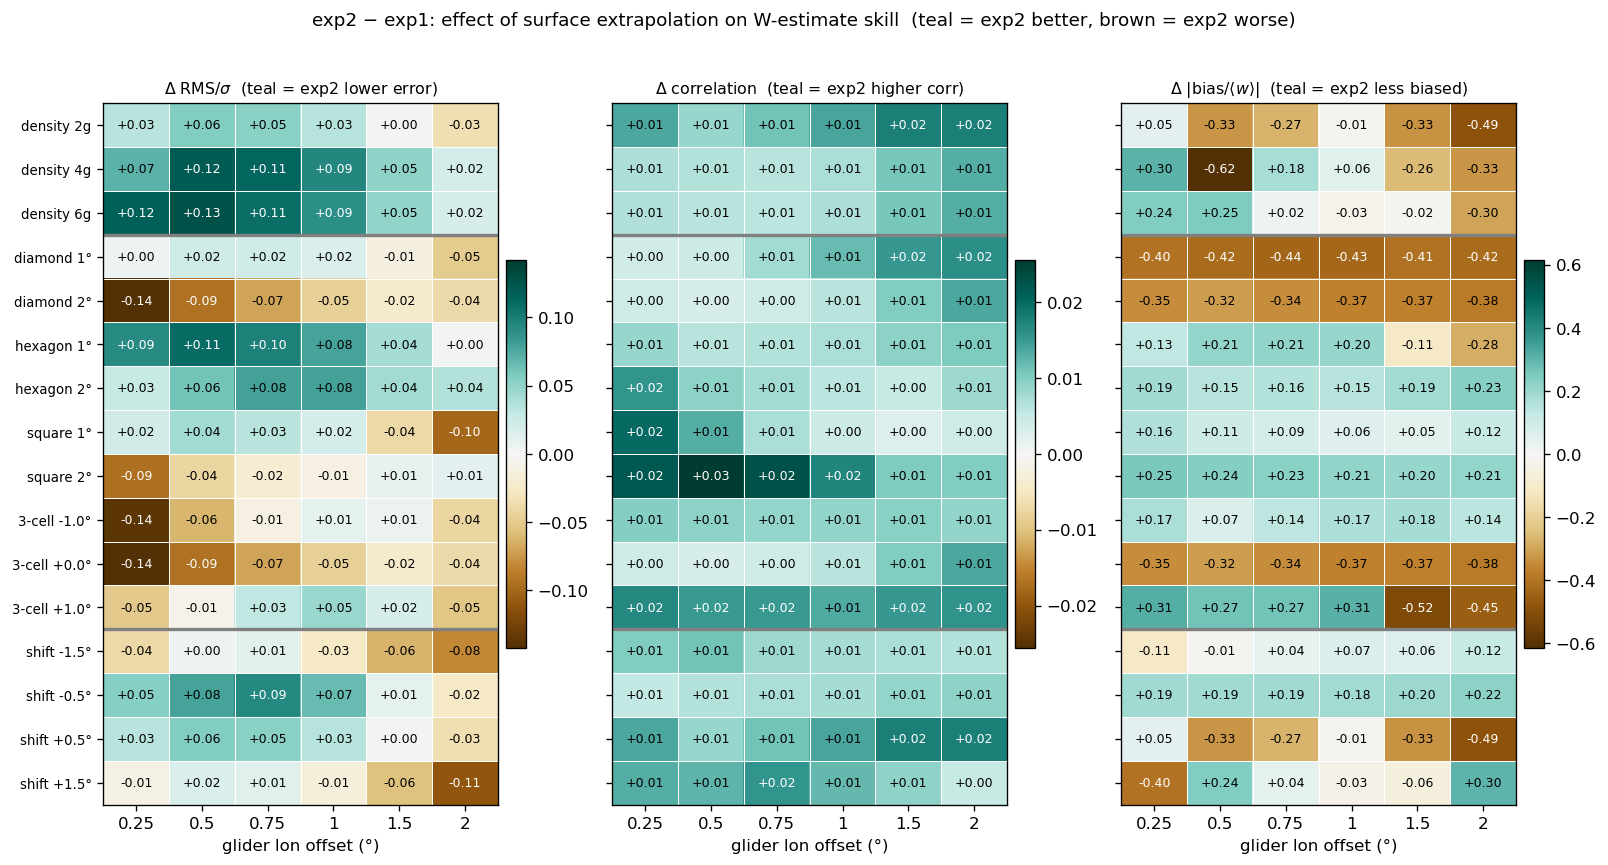

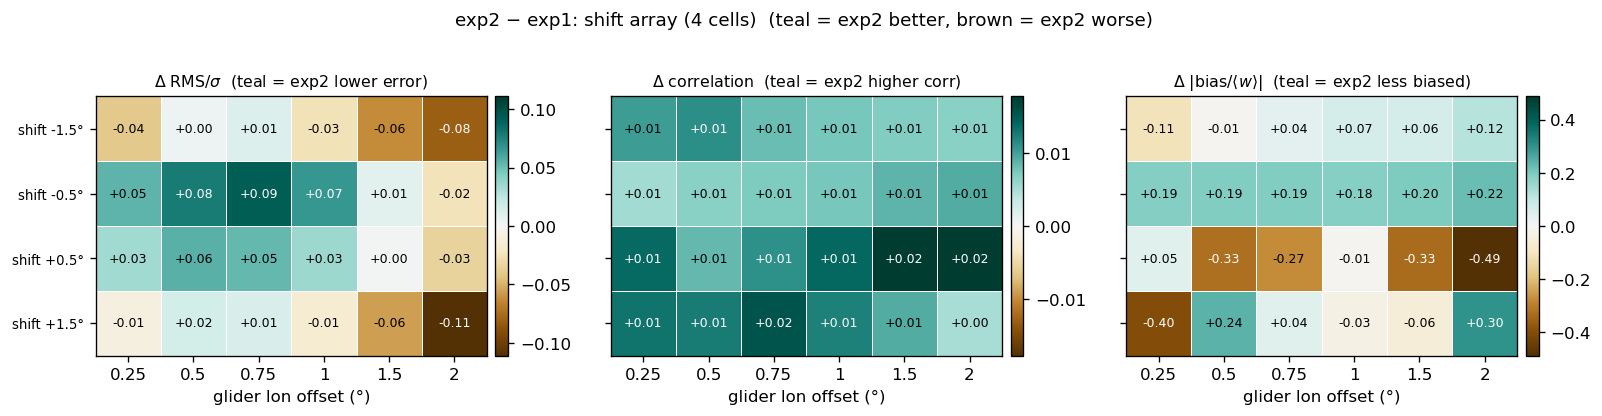

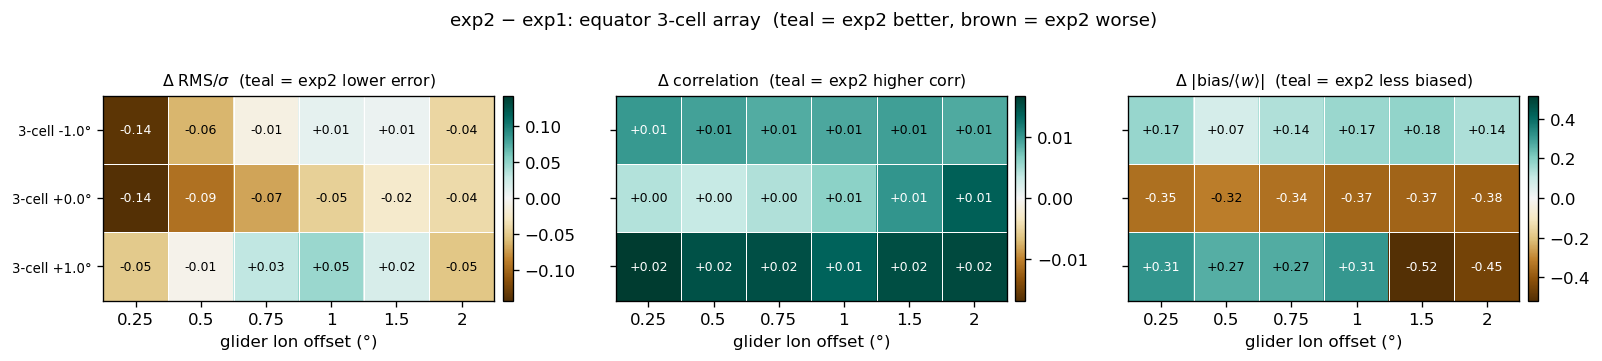

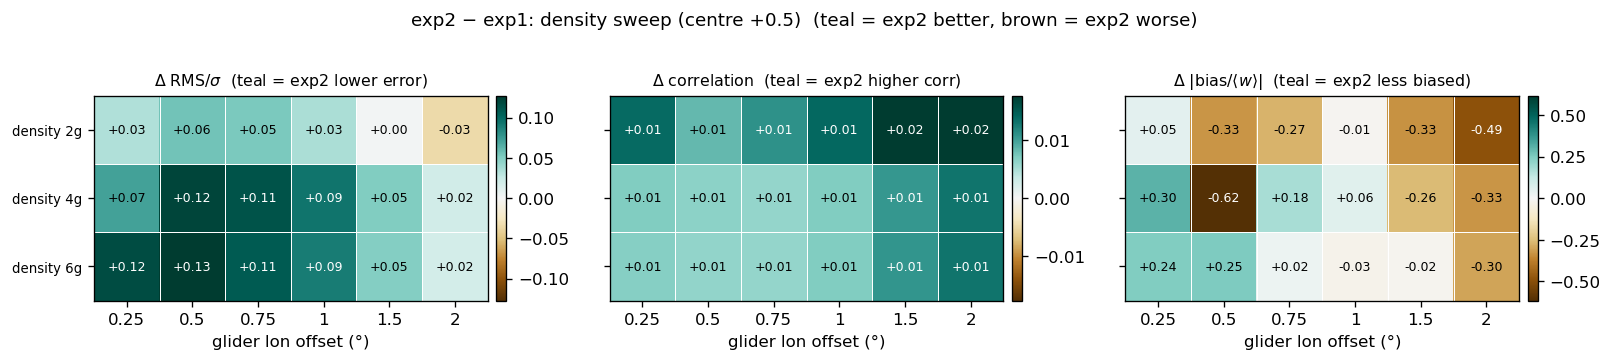

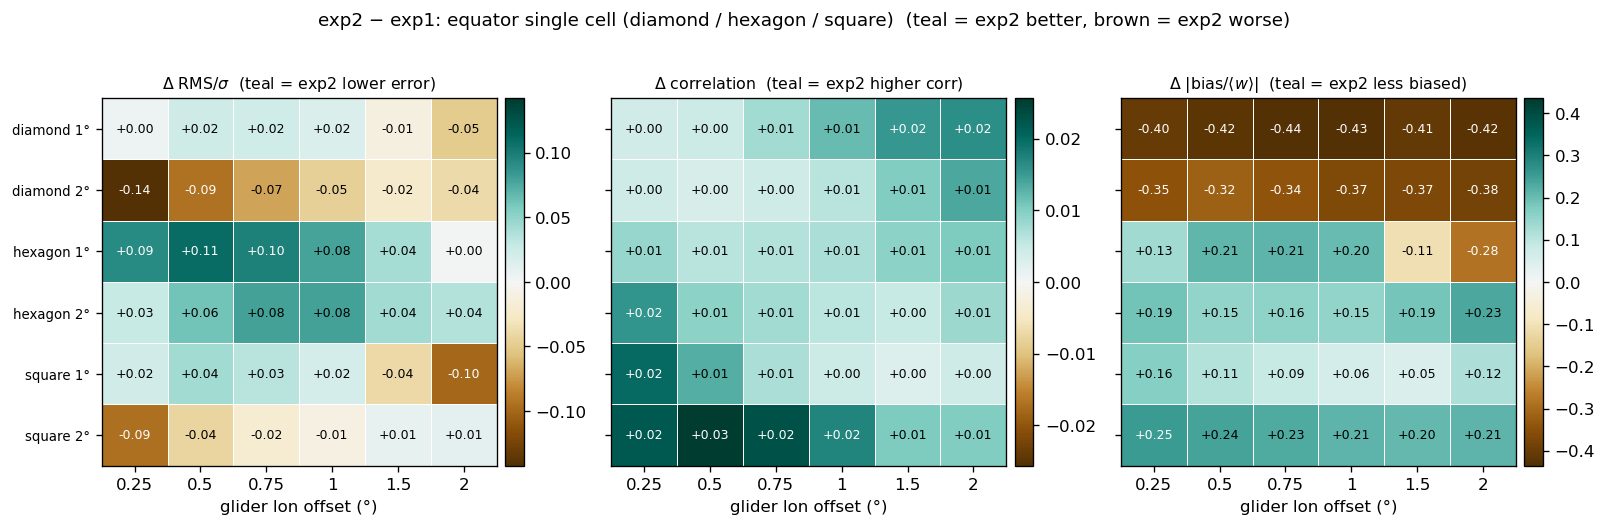

In [6]:
# Metric-change heatmaps: exp2 - exp1 per (config cell, width). Same "colored
# squares" layout as each summary.ipynb fig6, but every panel shows the CHANGE
# from turning on surface extrapolation, oriented so teal = exp2 better, brown =
# exp2 worse (diverging BrBG centred on zero). Improvement is defined per metric:
# RMS/sigma and |bias| use exp1 - exp2 (positive = exp2 smaller), correlation uses
# exp2 - exp1 (positive = exp2 higher). Descriptive only - it shows where the
# surface-extrapolation choice matters, not which is "correct".
# fig6 shows every family at once; fig6a-6d break it out one method per figure
# (same split as fig2a-2d / fig5a-5d) so each method's grid reads on its own.
from matplotlib.colors import TwoSlopeNorm

WIDTHS = [0.25, 0.5, 0.75, 1.0, 1.5, 2.0]
PAT_LABEL = {
    "density_2g": "density 2g", "density_4g": "density 4g", "density_6g": "density 6g",
    "equator_1deg": "diamond 1°", "equator_2deg": "diamond 2°",
    "equator_hex1deg": "hexagon 1°", "equator_hex2deg": "hexagon 2°",
    "equator_sq1deg": "square 1°", "equator_sq2deg": "square 2°",
    "equator_3cell": "3-cell", "shift": "shift",
}
ORDER = [
    ("density_2g", 0.5), ("density_4g", 0.5), ("density_6g", 0.5),
    ("equator_1deg", 0.0), ("equator_2deg", 0.0),
    ("equator_hex1deg", 0.0), ("equator_hex2deg", 0.0),
    ("equator_sq1deg", 0.0), ("equator_sq2deg", 0.0),
    ("equator_3cell", -1.0), ("equator_3cell", 0.0), ("equator_3cell", 1.0),
    ("shift", -1.5), ("shift", -0.5), ("shift", 0.5), ("shift", 1.5),
]
def _row_label(pat, lat):
    base = PAT_LABEL.get(pat, pat)
    return f"{base} {lat:+.1f}°" if pat in ("equator_3cell", "shift") else base
def _fam(pat):
    return "density" if pat.startswith("density") else "shift" if pat == "shift" else "equator"

def _lookup(df, pat, lat, w, col):
    sel = df[(df["pattern"] == pat) & np.isclose(df["center_lat"], lat)
             & np.isclose(df["width"], w)]
    return sel.iloc[0][col] if len(sel) else np.nan

# per-metric improvement grid (positive = exp2 better)
def _delta_grid(kind, order):
    g = np.full((len(order), len(WIDTHS)), np.nan)
    for i, (pat, lat) in enumerate(order):
        for j, w in enumerate(WIDTHS):
            if kind == "rms":
                a = _lookup(M[1], pat, lat, w, "norm_rms")
                b = _lookup(M[2], pat, lat, w, "norm_rms")
                g[i, j] = a - b                       # >0 => exp2 lower error
            elif kind == "corr":
                a = _lookup(M[1], pat, lat, w, "corr")
                b = _lookup(M[2], pat, lat, w, "corr")
                g[i, j] = b - a                       # >0 => exp2 higher corr
            else:  # fractional bias magnitude, bias / <w_model> (matches fig2-5)
                a = ot.frac_mean_bias(_lookup(M[1], pat, lat, w, "mean_bias"),
                                      _lookup(M[1], pat, lat, w, "w_model_mean"))
                b = ot.frac_mean_bias(_lookup(M[2], pat, lat, w, "mean_bias"),
                                      _lookup(M[2], pat, lat, w, "w_model_mean"))
                g[i, j] = abs(a) - abs(b)             # >0 => exp2 closer to unbiased
    return g

panels = [
    ("rms",  r"$\Delta$ RMS/$\sigma$  (teal = exp2 lower error)",     "{:+.2f}"),
    ("corr", r"$\Delta$ correlation  (teal = exp2 higher corr)",       "{:+.2f}"),
    ("bias", r"$\Delta$ |bias/$\langle w \rangle$|  (teal = exp2 less biased)", "{:+.2f}"),
]

def _delta_heatmap_fig(order, fname, suptitle, figsize):
    nrows = len(order)
    fig, axes = plt.subplots(1, 3, figsize=figsize, sharey=True)
    for ax, (kind, title, fmt) in zip(axes, panels):
        G = _delta_grid(kind, order)
        vmax = np.nanmax(np.abs(G))
        im = ax.imshow(G, aspect="auto", cmap="BrBG",
                       norm=TwoSlopeNorm(vmin=-vmax, vcenter=0.0, vmax=vmax))
        rgba = im.cmap(im.norm(G))
        lum = 0.299 * rgba[..., 0] + 0.587 * rgba[..., 1] + 0.114 * rgba[..., 2]
        for i in range(nrows):
            for j in range(len(WIDTHS)):
                if not np.isnan(G[i, j]):
                    ax.text(j, i, fmt.format(G[i, j]), ha="center", va="center",
                            fontsize=7.5, color="white" if lum[i, j] < 0.5 else "black")
        ax.set_xticks(range(len(WIDTHS)))
        ax.set_xticklabels([f"{w:g}" for w in WIDTHS])
        ax.set_xlabel("glider lon offset (°)")
        ax.set_title(title, fontsize=9.5)
        for i in range(1, nrows):
            if _fam(order[i][0]) != _fam(order[i - 1][0]):
                ax.axhline(i - 0.5, color="0.5", lw=2.0)
        ax.set_xticks(np.arange(-0.5, len(WIDTHS), 1), minor=True)
        ax.set_yticks(np.arange(-0.5, nrows, 1), minor=True)
        ax.grid(which="minor", color="white", lw=0.6)
        ax.tick_params(which="minor", length=0)
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.02)
    axes[0].set_yticks(range(nrows))
    axes[0].set_yticklabels([_row_label(p, l) for p, l in order], fontsize=8)
    fig.suptitle(suptitle, fontsize=11, y=0.995)
    fig.tight_layout(rect=[0, 0, 1, 0.98])
    fig.savefig(os.path.join(OUTDIR, fname), dpi=150, bbox_inches="tight")
    plt.show()

# Figure 6 - all families in one view
_delta_heatmap_fig(ORDER, "fig6_metric_heatmaps_compare.png",
                   "exp2 − exp1: effect of surface extrapolation on W-estimate skill  "
                   "(teal = exp2 better, brown = exp2 worse)",
                   figsize=(13.5, 7.2))

# Figures 6a-6d - one method per figure (same split as fig2a-2d / fig5a-5d).
# Each grid auto-scales its own colour range, so read colour within a figure.
EQS_ROWS = ["equator_1deg", "equator_2deg", "equator_hex1deg",
            "equator_hex2deg", "equator_sq1deg", "equator_sq2deg"]
SUB_ORDERS = [
    ("6a_shift", "shift array (4 cells)",
     [o for o in ORDER if o[0] == "shift"]),
    ("6b_equator3cell", "equator 3-cell array",
     [o for o in ORDER if o[0] == "equator_3cell"]),
    ("6c_density", "density sweep (centre +0.5)",
     [o for o in ORDER if o[0].startswith("density")]),
    ("6d_equator_single", "equator single cell (diamond / hexagon / square)",
     [o for o in ORDER if o[0] in EQS_ROWS]),
]
for tag, label, order in SUB_ORDERS:
    _delta_heatmap_fig(order, f"fig{tag}_compare.png",
                       f"exp2 − exp1: {label}  "
                       "(teal = exp2 better, brown = exp2 worse)",
                       figsize=(13.5, max(2.8, 0.46 * len(order) + 1.6)))
